In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score,silhouette_score,precision_score,mean_squared_error

from SCIKIT.Lesson32Knnmodifed import k_range



In [6]:
data=pd.read_csv("Test.csv")
df=pd.DataFrame(data)


In [7]:
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   str    
 2   Ever_Married     2577 non-null   str    
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   str    
 5   Profession       2589 non-null   str    
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   str    
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 276.0 KB


In [9]:
df.describe()



,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [10]:
df.isnull().sum()


ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience    269
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

In [11]:
df["Ever_Married"] = df["Ever_Married"].fillna(df["Ever_Married"].mode()[0])
print(df["Ever_Married"].isnull().sum())

0


In [12]:
df["Graduated"]=df["Graduated"].fillna(df["Graduated"].mode()[0])
print("Not fill values of Graduated",df["Graduated"].isnull().sum())

Not fill values of Graduated 0


In [13]:
df["Profession"] = df["Profession"].fillna("Unknown")

print("Not fill values of Profession",df["Profession"].isnull().sum())

Not fill values of Profession 0


In [14]:
df["Work_Experience"] = df["Work_Experience"].fillna(df["Work_Experience"].median())

print("Not fill value of Work_Experience",df["Work_Experience"].isnull().sum())

Not fill value of Work_Experience 0


In [15]:
df.isnull().sum(


)

ID                   0
Gender               0
Ever_Married         0
Age                  0
Graduated            0
Profession           0
Work_Experience      0
Spending_Score       0
Family_Size        113
Var_1               32
dtype: int64

In [16]:
df["Family_Size"]=df['Family_Size'].fillna(df["Family_Size"].median())
print(df["Family_Size"].isnull().sum())

0


In [17]:
df.isnull().sum()



ID                  0
Gender              0
Ever_Married        0
Age                 0
Graduated           0
Profession          0
Work_Experience     0
Spending_Score      0
Family_Size         0
Var_1              32
dtype: int64

In [18]:
df["Var_1"] = df["Var_1"].fillna(df["Var_1"].mode()[0])

df.isnull().sum()

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

In [19]:
# After all your fillna steps...

# Save to a new CSV file
df.to_csv("Cleaned_Test.csv", index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


In [20]:
df.describe()


,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2627.000000,2627.000000
mean,463433.918919,43.649791,2.393605,2.789874
std,2618.245698,16.967015,3.200165,1.527360
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,3.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [21]:
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,Unknown,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,1.0,Low,4.0,Cat_6


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns
data=pd.read_csv("Cleaned_Test.csv")
df=data.copy()

In [23]:
print("Rows",df.shape[0])
print("columns",df.shape[1])

Rows 2627
columns 10


In [24]:
df.sample(10,random_state=42)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
221,459678,Male,No,18,No,Healthcare,1.0,Low,5.0,Cat_6
318,460051,Male,No,39,Yes,Artist,7.0,Low,1.0,Cat_6
926,462094,Female,No,41,Yes,Healthcare,1.0,Low,1.0,Cat_6
2487,467493,Male,Yes,47,Yes,Executive,0.0,High,4.0,Cat_6
1420,463766,Female,Yes,61,Yes,Artist,0.0,Average,3.0,Cat_6
461,460470,Male,No,36,No,Healthcare,1.0,Low,4.0,Cat_4
678,461226,Male,Yes,45,Yes,Unknown,1.0,Low,2.0,Cat_6
32,459090,Male,No,31,No,Artist,1.0,Low,2.0,Cat_6
73,459213,Female,No,42,Yes,Healthcare,0.0,Low,4.0,Cat_6
2152,466324,Female,No,32,No,Engineer,0.0,Low,1.0,Cat_4


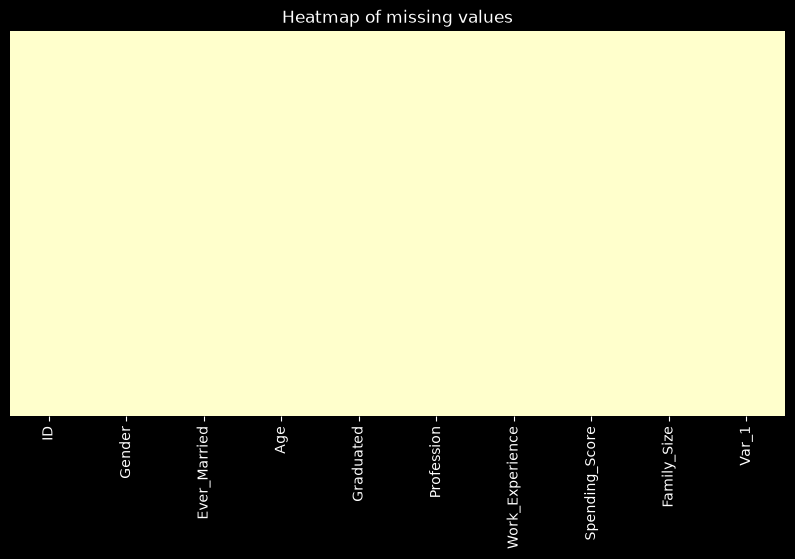

In [25]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="YlOrRd",
)
plt.title("Heatmap of missing values")
plt.savefig("Heatmap of missing values")

In [26]:
df.duplicated().sum()


np.int64(0)

In [27]:
print("Duplicate IDs:", df["ID"].duplicated().sum())


Duplicate IDs: 0


In [28]:
unique_counts=df.nunique()
print(unique_counts)

ID                 2627
Gender                2
Ever_Married          2
Age                  67
Graduated             2
Profession           10
Work_Experience      15
Spending_Score        3
Family_Size           9
Var_1                 7
dtype: int64


In [29]:
df =df.drop("ID",axis=1)
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,Female,Yes,69,No,Unknown,0.0,Low,1.0,Cat_6
3,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,Female,No,19,No,Marketing,1.0,Low,4.0,Cat_6


In [31]:
df.dtypes

Gender                 str
Ever_Married           str
Age                  int64
Graduated              str
Profession             str
Work_Experience    float64
Spending_Score         str
Family_Size        float64
Var_1                  str
dtype: object

In [32]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Ever_Married",
        "Graduated",
        "Profession",
        "Spending_Score",
        "Var_1"
    ],
    dtype=int
)

df_encoded.head()

,Age,Work_Experience,Family_Size,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,Profession_Artist,...,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,36,0.0,1.0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
1,37,8.0,4.0,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,0,1,0
2,69,0.0,1.0,1,0,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
3,59,11.0,2.0,0,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,19,1.0,4.0,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0


In [33]:
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

Original shape: (2627, 9)
Encoded shape: (2627, 29)


In [34]:
X=df_encoded
X.head()

,Age,Work_Experience,Family_Size,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,Profession_Artist,...,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,36,0.0,1.0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
1,37,8.0,4.0,0,1,0,1,0,1,0,...,1,0,0,0,0,0,0,0,1,0
2,69,0.0,1.0,1,0,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
3,59,11.0,2.0,0,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,19,1.0,4.0,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0


In [35]:
X.dtypes

Age                           int64
Work_Experience             float64
Family_Size                 float64
Gender_Female                 int64
Gender_Male                   int64
Ever_Married_No               int64
Ever_Married_Yes              int64
Graduated_No                  int64
Graduated_Yes                 int64
Profession_Artist             int64
Profession_Doctor             int64
Profession_Engineer           int64
Profession_Entertainment      int64
Profession_Executive          int64
Profession_Healthcare         int64
Profession_Homemaker          int64
Profession_Lawyer             int64
Profession_Marketing          int64
Profession_Unknown            int64
Spending_Score_Average        int64
Spending_Score_High           int64
Spending_Score_Low            int64
Var_1_Cat_1                   int64
Var_1_Cat_2                   int64
Var_1_Cat_3                   int64
Var_1_Cat_4                   int64
Var_1_Cat_5                   int64
Var_1_Cat_6                 

In [36]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [37]:
print(X_scaled.shape)


(2627, 29)


In [38]:
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)
print(X_scaled.shape)

Original shape: (2627, 9)
Encoded shape: (2627, 29)
(2627, 29)


In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

    print(
        f"K = {k} | "
        f"Inertia = {model.inertia_:.2f} | "
        f"Silhouette = {silhouette_scores[-1]:.3f}"
    )

K = 2 | Inertia = 66976.54 | Silhouette = 0.133
K = 3 | Inertia = 62886.26 | Silhouette = 0.127
K = 4 | Inertia = 59290.04 | Silhouette = 0.126
K = 5 | Inertia = 56707.82 | Silhouette = 0.144
K = 6 | Inertia = 54062.30 | Silhouette = 0.159
K = 7 | Inertia = 51638.84 | Silhouette = 0.167
K = 8 | Inertia = 48908.62 | Silhouette = 0.182
K = 9 | Inertia = 46414.05 | Silhouette = 0.204
K = 10 | Inertia = 43970.97 | Silhouette = 0.218


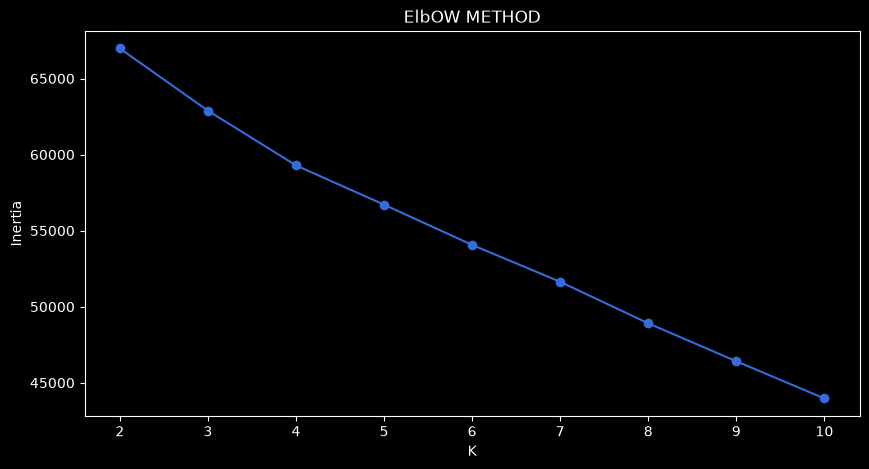

In [43]:
plt.figure(figsize=(10,5))
plt.plot(K_range, inertias,
         marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("ElbOW METHOD")
plt.show()

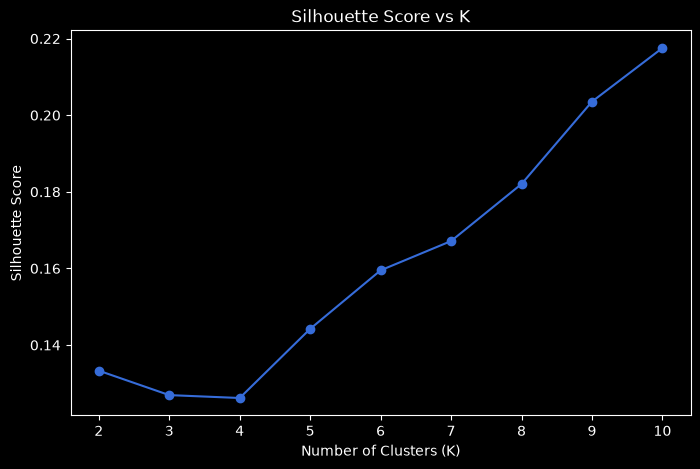

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()

In [46]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    670
1    603
2    962
3    172
4    220
Name: count, dtype: int64


In [47]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,Age,Work_Experience,Family_Size
Cluster,,,
0,39.061194,3.574627,1.967164
1,27.111111,2.109453,3.742952
2,48.319127,2.071726,2.829522
3,51.720930,2.145349,3.447674
4,76.227273,1.177273,1.995455


In [48]:
categorical_cols = [
    "Gender",
    "Ever_Married",
    "Graduated",
    "Profession",
    "Spending_Score",
    "Var_1"
]

for col in categorical_cols:
    print("\n" + "=" * 50)
    print(col)
    print(
        pd.crosstab(
            df["Cluster"],
            df[col],
            normalize="index"
        ).round(2)
    )


Gender
Gender   Female  Male
Cluster              
0          0.72  0.28
1          0.40  0.60
2          0.38  0.62
3          0.03  0.97
4          0.51  0.49

Ever_Married
Ever_Married    No   Yes
Cluster                 
0             0.74  0.26
1             0.90  0.10
2             0.00  1.00
3             0.03  0.97
4             0.06  0.94

Graduated
Graduated    No   Yes
Cluster              
0          0.09  0.91
1          0.90  0.10
2          0.23  0.77
3          0.48  0.52
4          0.42  0.58

Profession
Profession  Artist  Doctor  Engineer  Entertainment  Executive  Healthcare  \
Cluster                                                                      
0             0.44    0.12      0.12           0.12       0.00        0.09   
1             0.04    0.11      0.08           0.09       0.01        0.54   
2             0.51    0.10      0.11           0.17       0.00        0.03   
3             0.00    0.00      0.00           0.00       1.00        0.00   
4   